# Figure 5: SST forcing and 850-hPa model response

This notebook combines the SST forcing (P1, P2, and P2 − P1) with the corresponding 850-hPa streamfunction and wind response. It uses the compact plotting datasets stored in this folder. All labels and plot text are 22 pt.

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# USER TWEAK SECTION — edit these values to adjust the visual layout.
# PLOT_FONTSIZE changes every title, tick, and colorbar label simultaneously.
# FIGURE_* and GRID_* control the overall canvas, margins, hspace, and wspace.
# *_TITLE_PAD, COLORBAR_* and WIND_KEY_* control text and colorbar spacing.
# hspace increases/decreases the vertical space between the map rows.
# wspace increases/decreases the horizontal space between the left and right panels.
# -----------------------------------------------------------------------------
PLOT_FONTSIZE = 22
FIGURE_WIDTH, FIGURE_HEIGHT, FIGURE_DPI = 30, 16, 200
GRID_LEFT, GRID_RIGHT, GRID_BOTTOM, GRID_TOP = 0.045, 0.985, 0.16, 0.92
GRID_WSPACE, GRID_HSPACE = 0.12, 0.05
GRID_HEIGHT_RATIOS = [0.88, 1.12]
FORCING_TITLE_PAD, RESPONSE_TITLE_PAD = 14, 18
# These reproduce the original gambar4.8 wind-reference key placement.
WIND_KEY_X, WIND_KEY_Y, WIND_KEY_MAGNITUDE = 0.94, 0.94, 2
WIND_KEY_BOX_LEFT, WIND_KEY_BOX_BOTTOM = 0.8, 0.8975
WIND_KEY_BOX_WIDTH, WIND_KEY_BOX_HEIGHT = 0.2, 0.10
COLORBAR_HEIGHT = 0.020
FORCING_COLORBAR_OFFSET, RESPONSE_COLORBAR_OFFSET = 0.062, 0.092
COLORBAR_LABELPAD = 12

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': PLOT_FONTSIZE,
    'axes.titlesize': PLOT_FONTSIZE,
    'axes.labelsize': PLOT_FONTSIZE,
    'xtick.labelsize': PLOT_FONTSIZE,
    'ytick.labelsize': PLOT_FONTSIZE,
    'axes.unicode_minus': False,
})

# Resolve this notebook's data directory whether it is launched from Fig5 or a project root.


FIG5_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig5')
FORCING_PATH = FIG5_DIR / 'forcing_data.nc' if (FIG5_DIR / 'forcing_data.nc').exists() else FIG5_DIR / 'fig5_forcing_data.nc'
RESPONSE_PATH = FIG5_DIR / 'combined_ncep_r2_moist_lbm.nc'
OUTPUT_STEM = FIG5_DIR / 'Fig5_forcing_response'

print(f'Forcing data:  {FORCING_PATH}')
print(f'Response data: {RESPONSE_PATH}')


Forcing data:  /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig5/forcing_data.nc
Response data: /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig5/combined_ncep_r2_moist_lbm.nc


In [2]:
forcing_ds = xr.open_dataset(FORCING_PATH, decode_times=False)
response_ds = xr.open_dataset(RESPONSE_PATH, decode_times=False)

s_p1 = forcing_ds.s.isel(forcing=0, drop=True)
s_p2 = forcing_ds.s.isel(forcing=1, drop=True)
s_diff = s_p2 - s_p1

# Extract CTRL (P1BS_P1FRC) and EXP_B_S-123 (P2BS_P2FRC) at 850 hPa, time index 14
if 'experiment' in response_ds.dims and 'lev' in response_ds.dims:
    resp_ctrl = response_ds.sel(experiment='CTRL', lev=850.0).isel(time=14)
    resp_p2 = response_ds.sel(experiment='EXP_B_S-123', lev=850.0).isel(time=14)
    psi_p1 = resp_ctrl.psi / 1e6
    psi_p2 = resp_p2.psi / 1e6
    u_p1, u_p2 = resp_ctrl.u, resp_p2.u
    v_p1, v_p2 = resp_ctrl.v, resp_p2.v
else:
    psi_p1 = response_ds.psi.isel(experiment=0, drop=True) / 1e6
    psi_p2 = response_ds.psi.isel(experiment=1, drop=True) / 1e6
    u_p1, u_p2 = response_ds.u.isel(experiment=0, drop=True), response_ds.u.isel(experiment=1, drop=True)
    v_p1, v_p2 = response_ds.v.isel(experiment=0, drop=True), response_ds.v.isel(experiment=1, drop=True)

response_fields = [
    (psi_p1, u_p1, v_p1),
    (psi_p2, u_p2, v_p2),
    (psi_p2 - psi_p1, u_p2 - u_p1, v_p2 - v_p1),
]
print('Loaded P1 (CTRL), P2 (EXP_B_S-123), and difference response fields.')


Loaded P1 (CTRL), P2 (EXP_B_S-123), and difference response fields.


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shap

...

/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


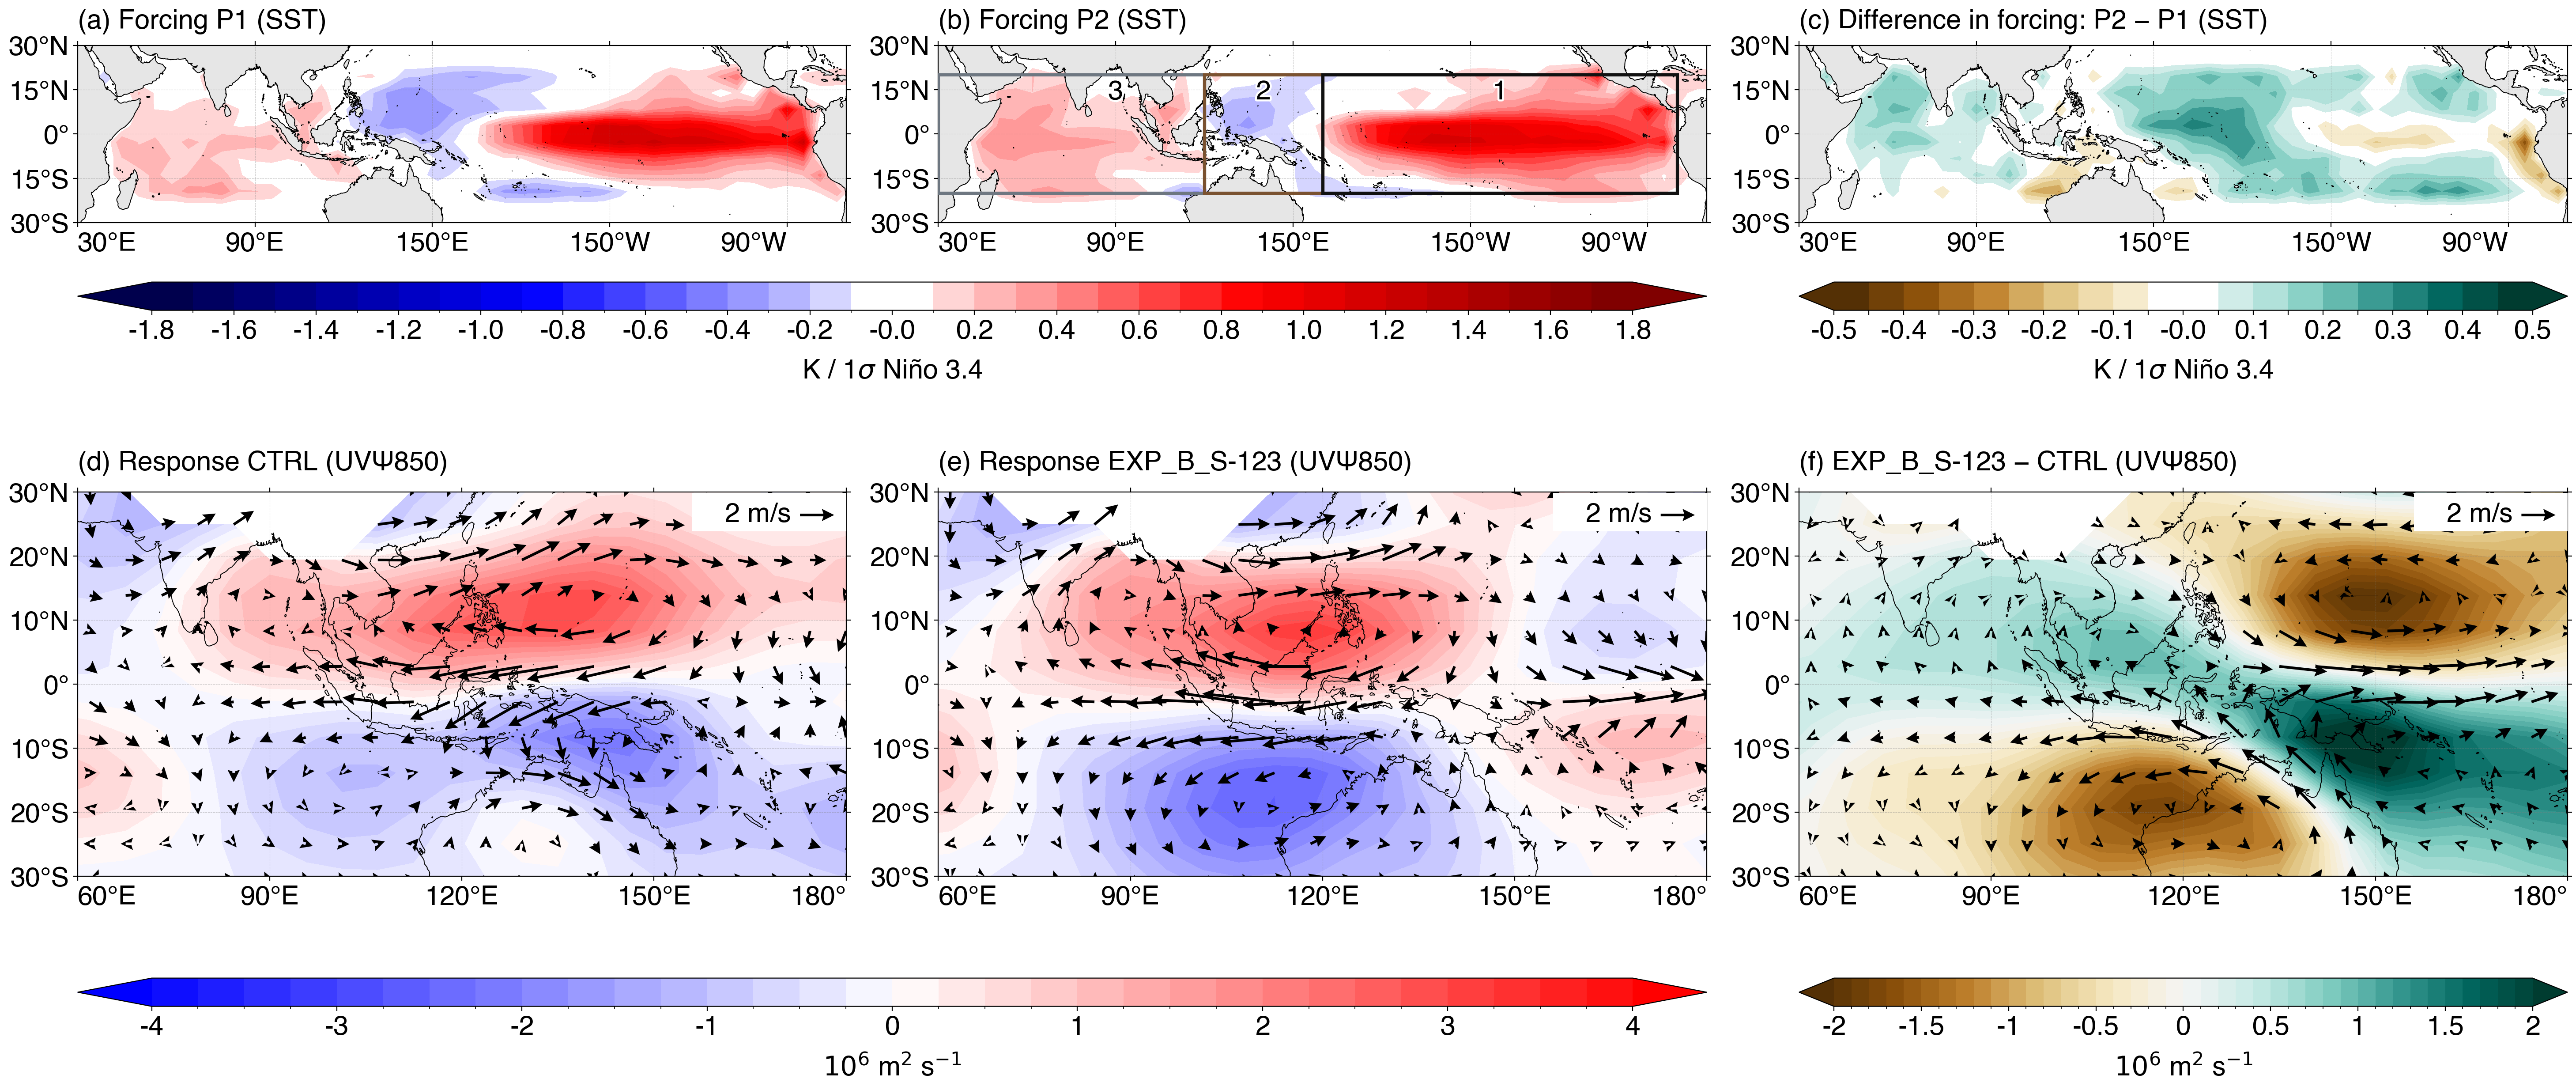

Saved /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig5/Fig5_forcing_response.png


In [3]:
def add_map_style(ax, extent, xticks, yticks):
    ax.coastlines(resolution='50m', color='black', linewidth=0.7, zorder=3)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelsize=PLOT_FONTSIZE)
    ax.gridlines(xlocs=xticks, ylocs=yticks, draw_labels=False, linewidth=0.4,
                 color='gray', alpha=0.4, linestyle='--')

def align_endpoint_tick_labels(ax, first_label, last_label):
    """Keep the first longitude label inside the map and the last one inside its map."""
    for label in ax.get_xticklabels():
        if first_label in label.get_text():
            label.set_ha('left')   # Text is on the right side of the first tick.
        elif last_label in label.get_text():
            label.set_ha('right')  # Text is on the left side of the last tick.

def label_every(interval):
    return FuncFormatter(lambda value, pos: f'{value:.1f}'
                         if np.isclose(value / interval, np.round(value / interval)) else '')

# Absolute values use the source scales. Difference panels use BrBG as requested.
forcing_levels = np.arange(-1.8, 1.8001, 0.1)
forcing_diff_levels = np.arange(-0.5, 0.5001, 0.05)
response_levels = np.arange(-4.0, 4.0001, 0.25)
response_diff_levels = np.arange(-2.0, 2.0001, 0.1)

def white_centered_cmap(base_name, levels, white_min, white_max):
    base = plt.colormaps[base_name]
    bin_colors = base(np.linspace(0, 1, len(levels) - 1))
    centers = (levels[:-1] + levels[1:]) / 2
    bin_colors[(centers >= white_min) & (centers <= white_max)] = [1, 1, 1, 1]
    colors = np.vstack([bin_colors[0], bin_colors, bin_colors[-1]])
    return mcolors.ListedColormap(colors)

forcing_cmap = white_centered_cmap('seismic', forcing_levels, -0.1, 0.1)
forcing_diff_cmap = white_centered_cmap('BrBG', forcing_diff_levels, -0.05, 0.05)
forcing_norm = mcolors.BoundaryNorm(forcing_levels, forcing_cmap.N, extend='both')
forcing_diff_norm = mcolors.BoundaryNorm(forcing_diff_levels, forcing_diff_cmap.N, extend='both')
response_norm = mcolors.BoundaryNorm(response_levels, plt.colormaps['bwr'].N, extend='both')
response_diff_norm = mcolors.BoundaryNorm(response_diff_levels, plt.colormaps['BrBG'].N, extend='both')

fig = plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=FIGURE_DPI)
gs = fig.add_gridspec(2, 3, left=GRID_LEFT, right=GRID_RIGHT, bottom=GRID_BOTTOM, top=GRID_TOP,
                      wspace=GRID_WSPACE, hspace=GRID_HSPACE, height_ratios=GRID_HEIGHT_RATIOS)
forcing_axes = [fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree(central_longitude=180)) for i in range(3)]
response_axes = [fig.add_subplot(gs[1, i], projection=ccrs.PlateCarree(central_longitude=180)) for i in range(3)]

forcing_data = [s_p1, s_p2, s_diff]
forcing_titles = ['(a) Forcing P1 (SST)', '(b) Forcing P2 (SST)', '(c) Difference in forcing: P2 − P1 (SST)']
forcing_contours = []
forcing_extent = [30, 290, -30, 30]  # Same longitude/latitude extent as gambar4.7.
forcing_xticks, forcing_yticks = [30, 90, 150, -150, -90], [-30, -15, 0, 15, 30]

# Fig. 8(a) forcing regions. Neutral outlines remain distinct from the red-blue SST shading.
forcing_region_specs = [
    ('3', 30, 120, '#6E7781', 90),   # charcoal gray (Region III); label at 90°E
    ('2', 120, 160, '#7A5230', 140), # dark brown (Region II)
    ('1', 160, 280, '#111111', 220), # black (Region I)
]

for i, (ax, data, title) in enumerate(zip(forcing_axes, forcing_data, forcing_titles)):
    values, longitude = add_cyclic_point(data.values, coord=data.lon.values, axis=1)
    contour = ax.contourf(longitude, data.lat.values, values,
                            levels=forcing_levels if i < 2 else forcing_diff_levels,
                            norm=forcing_norm if i < 2 else forcing_diff_norm,
                            cmap=forcing_cmap if i < 2 else forcing_diff_cmap,
                            transform=ccrs.PlateCarree(), extend='both')
    forcing_contours.append(contour)
    ax.add_feature(cfeature.LAND, facecolor='#E6E6E6', edgecolor='none', zorder=2)
    add_map_style(ax, forcing_extent, forcing_xticks, forcing_yticks)
    if i == 1:  # Show the Fig. 8(a) region boundaries only on panel (b), Forcing P2.
        for label, west, east, color, label_lon in forcing_region_specs:
            ax.add_patch(mpatches.Rectangle(
                (west, -20), east - west, 40, transform=ccrs.PlateCarree(),
                facecolor='none', edgecolor=color, linewidth=2.6,
                linestyle='-', zorder=5
            ))
            ax.text(label_lon, 14, label, transform=ccrs.PlateCarree(),
                    ha='center', va='center', color='black', fontsize=PLOT_FONTSIZE,
                    fontweight='bold', zorder=6,
                    path_effects=[pe.withStroke(linewidth=3.2, foreground='white')])
    ax.set_title(title, loc='left', pad=FORCING_TITLE_PAD, weight='bold', fontsize=PLOT_FONTSIZE)

response_titles = [
    r'(d) Response CTRL (UVΨ850)',
    r'(e) Response EXP_B_S-123 (UVΨ850)',
    r'(f) EXP_B_S-123 − CTRL (UVΨ850)',
]
response_contours = []
response_extent = [60, 180, -30, 30]
response_xticks, response_yticks = [60, 90, 120, 150, 180], [-30, -20, -10, 0, 10, 20, 30]

for i, (ax, (psi, u, v), title) in enumerate(zip(response_axes, response_fields, response_titles)):
    values, longitude = add_cyclic_point(psi.values, coord=response_ds.lon.values)
    contour = ax.contourf(longitude, response_ds.lat.values, values,
                            levels=response_levels if i < 2 else response_diff_levels,
                            norm=response_norm if i < 2 else response_diff_norm,
                            cmap='bwr' if i < 2 else 'BrBG',
                            transform=ccrs.PlateCarree(), extend='both')
    response_contours.append(contour)
    add_map_style(ax, response_extent, response_xticks, response_yticks)
    lon2d, lat2d = np.meshgrid(response_ds.lon.values, response_ds.lat.values)
    q = ax.quiver(lon2d, lat2d, u.values, v.values, transform=ccrs.PlateCarree(),
                  color='black', scale=45, width=0.0035,
                  headwidth=8 * (0.0020 / 0.0035),
                  headlength=8 * (0.0020 / 0.0035),
                  headaxislength=7 * (0.0020 / 0.0035),
                  minshaft=0, minlength=0, zorder=4)
    # Original gambar4.8 in-panel wind-reference key and its white background box.
    key_box = mpatches.Rectangle((WIND_KEY_BOX_LEFT, WIND_KEY_BOX_BOTTOM),
                                WIND_KEY_BOX_WIDTH, WIND_KEY_BOX_HEIGHT, transform=ax.transAxes,
                                facecolor='white', edgecolor='none', alpha=1, zorder=5)
    ax.add_patch(key_box)
    qk = ax.quiverkey(q, X=WIND_KEY_X, Y=WIND_KEY_Y, U=WIND_KEY_MAGNITUDE, label='2 m/s',
                      labelpos='W', coordinates='axes', fontproperties={'size': PLOT_FONTSIZE}, labelsep=0.1)
    qk.set_zorder(6)
    qk.text.set_zorder(7)
    ax.set_title(title, loc='left', pad=RESPONSE_TITLE_PAD, weight='bold', fontsize=PLOT_FONTSIZE)

# Place four horizontal colorbars in the whitespace beneath their associated panels.
fig.canvas.draw()
# Endpoint labels: 30°E (forcing) and 60°E (model) sit right of their ticks;
# 180° sits left of the model's final tick.
for ax in forcing_axes:
    align_endpoint_tick_labels(ax, '30°E', '90°W')
for ax in response_axes:
    align_endpoint_tick_labels(ax, '60°E', '180°')

def cbar_axes(ax_left, ax_right, y_offset):
    left, right = ax_left.get_position().x0, ax_right.get_position().x1
    y = ax_left.get_position().y0 - y_offset
    return fig.add_axes([left, y, right - left, COLORBAR_HEIGHT])

forcing_abs_cbar = fig.colorbar(forcing_contours[0], cax=cbar_axes(forcing_axes[0], forcing_axes[1], FORCING_COLORBAR_OFFSET),
                                orientation='horizontal', ticks=np.arange(-1.8, 1.8001, 0.2), extend='both')
forcing_diff_cbar = fig.colorbar(forcing_contours[2], cax=cbar_axes(forcing_axes[2], forcing_axes[2], FORCING_COLORBAR_OFFSET),
                                 orientation='horizontal', ticks=np.arange(-0.5, 0.51, 0.05), extend='both')
response_abs_cbar = fig.colorbar(response_contours[0], cax=cbar_axes(response_axes[0], response_axes[1], RESPONSE_COLORBAR_OFFSET),
                                 orientation='horizontal', ticks=np.arange(-4, 4.01, 1), extend='both')
response_diff_cbar = fig.colorbar(response_contours[2], cax=cbar_axes(response_axes[2], response_axes[2], RESPONSE_COLORBAR_OFFSET),
                                  orientation='horizontal', ticks=np.arange(-2, 2.0001, 0.5), extend='both')

for cbar, formatter, label in [
    (forcing_abs_cbar, label_every(0.2), r'K / 1$\sigma$ Niño 3.4'),
    (forcing_diff_cbar, label_every(0.1), r'K / 1$\sigma$ Niño 3.4'),
    (response_abs_cbar, FuncFormatter(lambda x, pos: f'{x:g}'), r'$10^6$ m$^2$ s$^{-1}$'),
    (response_diff_cbar, FuncFormatter(lambda x, pos: f'{x:g}'), r'$10^6$ m$^2$ s$^{-1}$'),
]:
    cbar.ax.xaxis.set_major_formatter(formatter)
    cbar.ax.tick_params(labelsize=PLOT_FONTSIZE)
    cbar.set_label(label, fontsize=PLOT_FONTSIZE, labelpad=COLORBAR_LABELPAD)

fig.savefig(OUTPUT_STEM.with_suffix('.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved {OUTPUT_STEM.with_suffix('.png')}")
